# 06- Model interpretability

## Objectif
Expliquer le modèle final et transformer les prédictions en actions métier

In [11]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance

df = pd.read_csv("../01_Data/processed/churn_features.csv")

if "customerID" in df.columns:
    df = df.drop(columns=["customerID"])

X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = joblib.load("../04_Models/best_model.pkl")


In [12]:
result = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="f1",
    n_jobs=1
)

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance_mean": result.importances_mean
}).sort_values("importance_mean", ascending=False)

importance_df.head(15)


,feature,importance_mean
19,avg_charge_per_tenure,0.007471
4,tenure,0.004878
16,PaymentMethod,0.002908
18,TotalCharges,0.002505
20,has_fiber,0.002383
7,InternetService,0.001669
21,is_month_to_month,0.000891
17,MonthlyCharges,0.000720
1,SeniorCitizen,0.000609
0,gender,0.000595


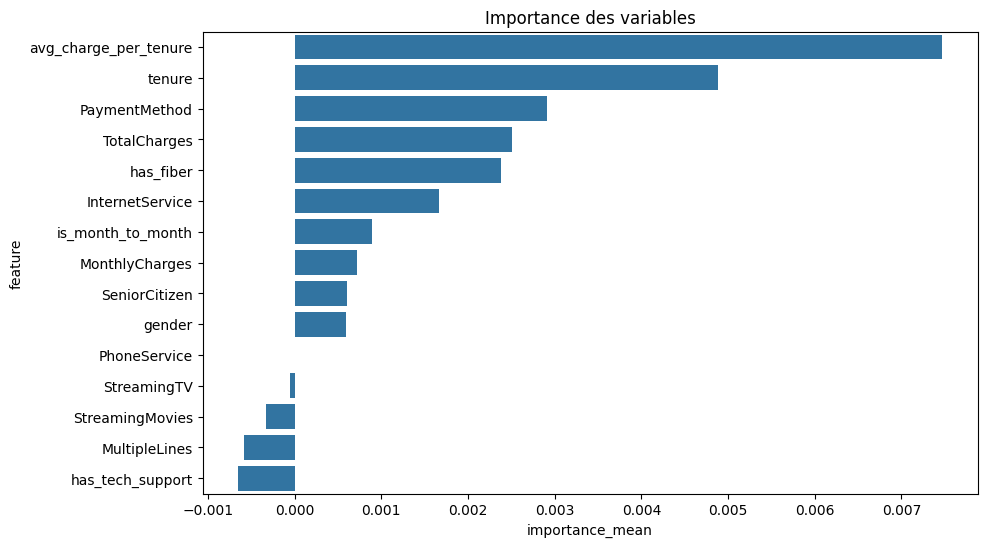

In [13]:
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15), x="importance_mean", y="feature")
plt.title("Importance des variables")
plt.show()


## Interprétation
Cette étape permet d'expliquer quels facteurs influencent le plus le churn.


In [14]:
# Scoring
probabilities = model.predict_proba(X_test)[:, 1]

scoring_df = X_test.copy()
scoring_df["churn_probability"] = probabilities

scoring_df["risk_segment"] = pd.cut(
    scoring_df["churn_probability"],
    bins=[0, 0.3, 0.6, 0.8, 1],
    labels=["Faible risque", "Risque moyen", "Risque élevé", "Très haut risque"],
    include_lowest=True
)

def recommend_action(probability):
    if probability >= 0.8:
        return "Intervention prioritaire"
    elif probability >= 0.6:
        return "Contact conseiller"
    elif probability >= 0.3:
        return "Campagne personnalisée"
    else:
        return "Fidélisation classique"

scoring_df["recommended_action"] = scoring_df["churn_probability"].apply(recommend_action)

scoring_df[["churn_probability", "risk_segment", "recommended_action"]].head(10)

,churn_probability,risk_segment,recommended_action
437,0.032168,Faible risque,Fidélisation classique
2280,0.654621,Risque élevé,Contact conseiller
2235,0.074272,Faible risque,Fidélisation classique
4460,0.368321,Risque moyen,Campagne personnalisée
3761,0.049224,Faible risque,Fidélisation classique
5748,0.606140,Risque élevé,Contact conseiller
3568,0.432131,Risque moyen,Campagne personnalisée
2976,0.073562,Faible risque,Fidélisation classique
5928,0.055375,Faible risque,Fidélisation classique
1639,0.518274,Risque moyen,Campagne personnalisée


## Interprétation métier
Les scores sont transformés en recommandations exploitables pour réduire l'attrition.


In [15]:
scoring_df[["churn_probability", "risk_segment", "recommended_action"]].to_csv(
    "../08_Optimization_Strategy/customer_churn_scoring.csv",
    index=False
)

print("Scoring client sauvegardé.")


Scoring client sauvegardé.
